## 1. Setup & Configuration {#setup}

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import json
import math
from typing import Dict, List, Tuple, Optional
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


In [2]:
# Define project paths
REPO_ROOT = Path.cwd().parent
DATA_DIR = REPO_ROOT / "data" / "input"
OUTPUT_DIR = REPO_ROOT / "data" / "output"
MODELS_DIR = REPO_ROOT / "models"
EXPERIMENTS_DIR = MODELS_DIR / "experiments"
OMEGA_OUTPUT_FILE = OUTPUT_DIR / "omega_value.json"

# Create output directory if needed
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")

Repository root: d:\docs\MADS\699
Data directory: d:\docs\MADS\699\data\input
Models directory: d:\docs\MADS\699\models


## 2. Dataset Variability Analysis {#variability}

Calculate the Omega parameter (Dirichlet precision) to quantify inter-image variability in the dataset.

**Omega Interpretation:**
- **High Omega (>10)**: Low variability - images are similar, fewer samples needed
- **Medium Omega (5-10)**: Moderate variability - typical dataset characteristics
- **Low Omega (<5)**: High variability - images are diverse, more samples needed

In [3]:
def calculate_omega_from_predictions(predictions_dir: Path) -> Optional[Dict]:
    """
    Calculate Omega (Dirichlet precision parameter) from model predictions.
    
    Omega = (mean * (1 - mean) / variance) - 1
    
    Returns:
        Dictionary with omega, mean_accuracy, variance, and interpretation
    """
    if not predictions_dir.exists():
        print(f"❌ Predictions directory not found: {predictions_dir}")
        return None
    
    # Collect per-image accuracy metrics
    image_accuracies = []
    
    for pred_file in predictions_dir.glob("*.txt"):
        try:
            with open(pred_file, 'r') as f:
                lines = f.readlines()
                # Parse prediction format (class, x, y, w, h, confidence)
                confidences = [float(line.split()[5]) for line in lines if len(line.split()) >= 6]
                if confidences:
                    image_accuracies.append(np.mean(confidences))
        except Exception as e:
            continue
    
    if len(image_accuracies) < 2:
        print("❌ Insufficient prediction data for Omega calculation")
        return None
    
    # Calculate statistics
    mean_acc = np.mean(image_accuracies)
    var_acc = np.var(image_accuracies, ddof=1)
    
    if var_acc == 0 or mean_acc == 0 or mean_acc == 1:
        print("❌ Cannot calculate Omega: invalid variance or mean")
        return None
    
    # Calculate Omega
    omega = (mean_acc * (1 - mean_acc) / var_acc) - 1
    
    # Interpret variability
    if omega > 10:
        variability = "Low"
    elif omega > 5:
        variability = "Medium"
    else:
        variability = "High"
    
    return {
        'omega': omega,
        'mean_accuracy': mean_acc,
        'variance_accuracy': var_acc,
        'num_images': len(image_accuracies),
        'variability_level': variability,
        'std_dev': np.sqrt(var_acc)
    }

def estimate_omega_from_ground_truth(gt_dir: Path) -> Optional[Dict]:
    """
    Estimate Omega from ground truth label diversity.
    Uses the variance in number of bounding boxes per image as a proxy.
    """
    labels_dir = gt_dir / "labels" if (gt_dir / "labels").exists() else gt_dir
    
    label_files = list(labels_dir.glob("*.txt"))
    if len(label_files) < 2:
        return None
    
    box_counts = []
    for lf in label_files:
        try:
            with open(lf, 'r') as f:
                box_counts.append(len(f.readlines()))
        except:
            continue
    
    if len(box_counts) < 2:
        return None
    
    mean_boxes = np.mean(box_counts)
    var_boxes = np.var(box_counts, ddof=1)
    
    # Normalize to [0,1] range for Omega calculation
    max_boxes = max(box_counts)
    if max_boxes == 0:
        return None
    
    normalized_mean = mean_boxes / max_boxes
    normalized_var = var_boxes / (max_boxes ** 2)
    
    if normalized_var == 0 or normalized_mean == 0 or normalized_mean == 1:
        return None
    
    omega = (normalized_mean * (1 - normalized_mean) / normalized_var) - 1
    
    if omega > 10:
        variability = "Low"
    elif omega > 5:
        variability = "Medium"
    else:
        variability = "High"
    
    return {
        'omega': omega,
        'mean_accuracy': normalized_mean,
        'variance_accuracy': normalized_var,
        'num_images': len(box_counts),
        'variability_level': variability,
        'estimation_method': 'ground_truth_diversity'
    }

print("✓ Omega calculation functions defined")

✓ Omega calculation functions defined


In [4]:
# Calculate or load Omega value
print("=" * 80)
print("DATASET VARIABILITY ANALYSIS (OMEGA CALCULATION)")
print("=" * 80)

omega_data = None

# Try to load existing Omega value
if OMEGA_OUTPUT_FILE.exists():
    try:
        with open(OMEGA_OUTPUT_FILE, 'r') as f:
            omega_data = json.load(f)
        print(f"\n✓ Loaded existing Omega value: {omega_data['omega']:.2f}")
        print(f"  Variability Level: {omega_data['variability_level']}")
        print(f"  Based on {omega_data['num_images']} images")
    except Exception as e:
        print(f"⚠ Error loading Omega file: {e}")

# Calculate Omega if not available
if omega_data is None:
    print("\nCalculating Omega from ground truth data...")
    gt_dir = DATA_DIR / "ground-truth"
    
    omega_data = estimate_omega_from_ground_truth(gt_dir)
    
    if omega_data:
        # Save for future use
        with open(OMEGA_OUTPUT_FILE, 'w') as f:
            json.dump(omega_data, f, indent=2)
        print(f"\n✓ Calculated Omega: {omega_data['omega']:.2f}")
        print(f"  Variability Level: {omega_data['variability_level']}")
        print(f"  Saved to: {OMEGA_OUTPUT_FILE}")
    else:
        print("⚠ Could not calculate Omega. Using default value: 4.5 (High Variability)")
        omega_data = {
            'omega': 4.5,
            'variability_level': 'High',
            'estimation_method': 'default'
        }

# Display detailed Omega analysis
print("\n" + "-" * 80)
print("OMEGA INTERPRETATION:")
print("-" * 80)
print(f"\nOmega = {omega_data['omega']:.2f}")
print(f"Variability Level: {omega_data['variability_level']}")
print(f"\nMeaning:")
if omega_data['omega'] > 10:
    print("  • Images are very similar (low variability)")
    print("  • Fewer samples needed for statistical validity")
    print("  • Augmentation may have limited benefit")
elif omega_data['omega'] > 5:
    print("  • Images have moderate variability")
    print("  • Standard sample sizes apply")
    print("  • Augmentation provides reasonable diversity")
else:
    print("  • Images are highly diverse (high variability)")
    print("  • More samples needed for statistical validity")
    print("  • Augmentation is valuable for coverage")

DATASET VARIABILITY ANALYSIS (OMEGA CALCULATION)

✓ Loaded existing Omega value: 1.01
  Variability Level: High
  Based on 165 images

--------------------------------------------------------------------------------
OMEGA INTERPRETATION:
--------------------------------------------------------------------------------

Omega = 1.01
Variability Level: High

Meaning:
  • Images are highly diverse (high variability)
  • More samples needed for statistical validity
  • Augmentation is valuable for coverage


## 3. Statistical Validation {#validation}

Validate dataset composition and calculate confidence intervals for model performance.

In [5]:
# Statistical validation functions
def calculate_confidence_interval(sample_size: int, proportion: float, confidence_level: float = 0.95):
    """
    Calculate confidence interval for a proportion.
    
    Args:
        sample_size: Number of samples (n)
        proportion: Observed proportion/accuracy (p)
        confidence_level: Confidence level (default 0.95 for 95%)
    
    Returns:
        (margin_of_error, lower_bound, upper_bound)
    """
    if sample_size == 0:
        return None, None, None
    
    z_score = scipy_stats.norm.ppf((1 + confidence_level) / 2)
    std_error = math.sqrt((proportion * (1 - proportion)) / sample_size)
    margin_of_error = z_score * std_error
    
    lower_bound = max(0.0, proportion - margin_of_error)
    upper_bound = min(1.0, proportion + margin_of_error)
    
    return margin_of_error, lower_bound, upper_bound

def calculate_required_sample_size(margin_of_error: float = 0.05, 
                                   confidence_level: float = 0.85,
                                   expected_proportion: float = 0.5,
                                   omega: float = None):
    """
    Calculate required sample size for desired confidence interval.
    Formula: n = (z^2 * p * (1-p)) / e^2
    
    If omega is provided, adjusts for dataset variability:
    n_effective = n × (1 + 1/omega)
    """
    z_score = scipy_stats.norm.ppf((1 + confidence_level) / 2)
    n = (z_score**2 * expected_proportion * (1 - expected_proportion)) / (margin_of_error**2)
    
    # Apply Omega adjustment if provided
    if omega is not None and omega > 0:
        n = n * (1 + 1/omega)
    
    return int(math.ceil(n))

def identify_original_images(image_dir: Path):
    """
    Identify original vs augmented images.
    Augmented images have pattern: *_aug{N}_{type}.jpg
    """
    images_subdir = image_dir / "images"
    search_dir = images_subdir if images_subdir.exists() else image_dir
    
    image_files = sorted(search_dir.glob("*.jpg")) + sorted(search_dir.glob("*.png"))
    
    original_images = []
    augmented_images = []
    augmentation_map = {}
    
    for img in image_files:
        if "_aug" in img.stem:
            augmented_images.append(img)
            # Extract original name
            base_name = img.stem.split('_aug')[0]
            if base_name not in augmentation_map:
                augmentation_map[base_name] = []
            augmentation_map[base_name].append(img)
        else:
            original_images.append(img)
    
    return original_images, augmented_images, augmentation_map

print("✓ Statistical validation functions defined")

✓ Statistical validation functions defined


In [6]:
# Analyze dataset composition
print("=" * 80)
print("DATASET COMPOSITION ANALYSIS")
print("=" * 80)

composition_stats = {}

for split_name in ["training", "validation", "testing"]:
    split_dir = DATA_DIR / split_name
    
    if not split_dir.exists():
        print(f"\n⚠ {split_name.upper()}: Directory not found")
        continue
    
    original_imgs, augmented_imgs, aug_map = identify_original_images(split_dir)
    
    # Calculate augmentation statistics
    if aug_map:
        aug_counts = [len(augs) for augs in aug_map.values()]
        avg_augs = np.mean(aug_counts)
        min_augs = min(aug_counts)
        max_augs = max(aug_counts)
    else:
        avg_augs = min_augs = max_augs = 0
    
    print(f"\n{split_name.upper()}:")
    print(f"  Original images        : {len(original_imgs)}")
    print(f"  Augmented samples      : {len(augmented_imgs)}")
    print(f"  Unique source bases    : {len(aug_map)}")
    print(f"  Avg augmentations/base : {avg_augs:.1f}")
    print(f"  Min/Max augmentations  : {min_augs}/{max_augs}")
    
    composition_stats[split_name] = {
        'original': len(original_imgs),
        'augmented': len(augmented_imgs),
        'total': len(original_imgs) + len(augmented_imgs),
        'unique_bases': len(aug_map)
    }

# Calculate totals
total_original = sum(s['original'] for s in composition_stats.values())
total_augmented = sum(s['augmented'] for s in composition_stats.values())
total_all = total_original + total_augmented

print(f"\n{'='*80}")
print(f"TOTALS:")
print(f"  Original images    : {total_original}")
print(f"  Augmented samples  : {total_augmented}")
print(f"  Total samples      : {total_all}")
print(f"  Augmentation ratio : {total_augmented/total_original:.1f}x" if total_original > 0 else "  Augmentation ratio : N/A")

DATASET COMPOSITION ANALYSIS

TRAINING:
  Original images        : 0
  Augmented samples      : 2224
  Unique source bases    : 164
  Avg augmentations/base : 13.6
  Min/Max augmentations  : 8/18

VALIDATION:
  Original images        : 0
  Augmented samples      : 654
  Unique source bases    : 163
  Avg augmentations/base : 4.0
  Min/Max augmentations  : 1/8

TESTING:
  Original images        : 0
  Augmented samples      : 481
  Unique source bases    : 159
  Avg augmentations/base : 3.0
  Min/Max augmentations  : 1/8

TOTALS:
  Original images    : 0
  Augmented samples  : 3359
  Total samples      : 3359
  Augmentation ratio : N/A


In [7]:
# Sample size requirements
print("\n" + "=" * 80)
print("SAMPLE SIZE REQUIREMENTS FOR STATISTICAL VALIDITY")
print("=" * 80)

desired_confidence = 0.85  # 85%
desired_margin = 0.05  # ±5%

# Conservative estimate (50% accuracy)
required_n_conservative = calculate_required_sample_size(
    margin_of_error=desired_margin,
    confidence_level=desired_confidence,
    expected_proportion=0.5
)

# Omega-adjusted conservative estimate
required_n_conservative_omega = calculate_required_sample_size(
    margin_of_error=desired_margin,
    confidence_level=desired_confidence,
    expected_proportion=0.5,
    omega=omega_data['omega']
)

print(f"\nTarget: {desired_confidence*100:.0f}% confidence interval with ±{desired_margin*100:.0f}% margin")
print(f"\n1. Conservative Estimate (assuming 50% accuracy):")
print(f"   Without Omega adjustment: {required_n_conservative} images")
print(f"   With Omega adjustment (Ω={omega_data['omega']:.2f}): {required_n_conservative_omega} images")
print(f"   Omega impact: {required_n_conservative_omega - required_n_conservative:+d} images ({((required_n_conservative_omega - required_n_conservative)/required_n_conservative*100):+.1f}%)")

# Calculate for different expected accuracies
print(f"\n2. Required samples at different expected accuracies (with Omega={omega_data['omega']:.2f}):")
for expected_acc in [0.70, 0.80, 0.90, 0.95]:
    n_base = calculate_required_sample_size(desired_margin, desired_confidence, expected_acc)
    n_omega = calculate_required_sample_size(desired_margin, desired_confidence, expected_acc, omega=omega_data['omega'])
    print(f"   {expected_acc*100:.0f}% accuracy: {n_base:4d} samples (base) → {n_omega:4d} samples (Ω-adjusted)")

# Check if we have sufficient samples
print(f"\n3. Current Dataset Status:")
print(f"   Total augmented samples: {total_augmented}")
print(f"\n   Against base conservative estimate ({required_n_conservative}):")
if total_augmented >= required_n_conservative:
    print(f"   ✓ SUFFICIENT")
else:
    shortfall = required_n_conservative - total_augmented
    print(f"   ⚠ INSUFFICIENT - need {shortfall} more samples")

print(f"\n   Against Omega-adjusted estimate ({required_n_conservative_omega}):")
if total_augmented >= required_n_conservative_omega:
    print(f"   ✓ SUFFICIENT")
else:
    shortfall = required_n_conservative_omega - total_augmented
    print(f"   ⚠ INSUFFICIENT - need {shortfall} more samples")


SAMPLE SIZE REQUIREMENTS FOR STATISTICAL VALIDITY

Target: 85% confidence interval with ±5% margin

1. Conservative Estimate (assuming 50% accuracy):
   Without Omega adjustment: 208 images
   With Omega adjustment (Ω=1.01): 412 images
   Omega impact: +204 images (+98.1%)

2. Required samples at different expected accuracies (with Omega=1.01):
   70% accuracy:  175 samples (base) →  346 samples (Ω-adjusted)
   80% accuracy:  133 samples (base) →  264 samples (Ω-adjusted)
   90% accuracy:   75 samples (base) →  149 samples (Ω-adjusted)
   95% accuracy:   40 samples (base) →   79 samples (Ω-adjusted)

3. Current Dataset Status:
   Total augmented samples: 3359

   Against base conservative estimate (208):
   ✓ SUFFICIENT

   Against Omega-adjusted estimate (412):
   ✓ SUFFICIENT


### Why We Need Model Accuracy for Precise Sample Size Calculation

**The Challenge:** The required sample size formula depends critically on the expected accuracy:

$$n = \frac{z^2 \times p \times (1-p)}{e^2}$$

Where:
- **n** = required sample size
- **z** = z-score for confidence level (1.44 for 85% CI)
- **p** = expected proportion/accuracy
- **e** = margin of error (0.05 for ±5%)

**The Problem with Conservative Estimates:**

Without knowing the actual model performance, we must use a **conservative estimate** (p = 0.5), which assumes 50% accuracy. This is the worst-case scenario because:

- At p = 0.5, the variance **p × (1-p) = 0.25** is **maximum**
- This produces the **largest possible sample size requirement**
- It's safe but often **drastically overestimates** the true need

**Why Accuracy Matters:**

The term **p × (1-p)** represents the variance of a binomial proportion:
- At 50% accuracy: 0.5 × 0.5 = **0.250** (maximum variance)
- At 90% accuracy: 0.9 × 0.1 = **0.090** (64% less variance)
- At 99% accuracy: 0.99 × 0.01 = **0.010** (96% less variance!)

**Real-World Impact:**

For 85% CI with ±5% margin:
- Conservative (50%): **Requires ~133 samples**
- High accuracy (99%): **Requires ~6 samples** (95% reduction!)

This is why we calculate conservative estimates first, then refine them once we have actual model performance data. The actual model accuracy (Section 4) provides the precise sample size needed for statistical validity.

**Key Takeaway:** Without model accuracy, we must assume the worst case. Once we train and evaluate the model, we can dramatically reduce the required sample size if performance is high.

In [8]:
# Calculate required sample size using ACTUAL model accuracy
print("\n" + "=" * 80)
print("ACTUAL MODEL ACCURACY IMPACT ON SAMPLE SIZE")
print("=" * 80)

# Note: We need to run the model analysis first to get actual accuracy
# This cell will be updated after model metrics are loaded
# For now, we'll use a placeholder that will be filled in later

print("\nNOTE: This calculation uses the actual model performance metrics.")
print("      Model analysis must be completed first (see Section 4).\n")

# We'll define a function that can be called after model analysis
def calculate_sample_size_with_actual_accuracy(actual_accuracy, confidence_level=0.85, margin_of_error=0.05, omega=None):
    """
    Calculate required sample size using actual model accuracy.
    
    Args:
        actual_accuracy: Actual mAP50 from trained model (e.g., 0.995)
        confidence_level: Confidence level (default 0.85 for 85%)
        margin_of_error: Margin of error (default 0.05 for ±5%)
        omega: Dirichlet precision parameter for variability adjustment (optional)
    
    Returns:
        Required sample size (int)
    """
    z_score = scipy_stats.norm.ppf((1 + confidence_level) / 2)
    
    # Formula: n = (z^2 * p * (1-p)) / e^2
    # where p = actual_accuracy
    n = (z_score**2 * actual_accuracy * (1 - actual_accuracy)) / (margin_of_error**2)
    
    # Apply Omega adjustment if provided
    if omega is not None and omega > 0:
        n = n * (1 + 1/omega)
    
    return int(math.ceil(n))

print("✓ Actual accuracy sample size calculation function defined")
print("  (Will be applied after model analysis is complete)")



ACTUAL MODEL ACCURACY IMPACT ON SAMPLE SIZE

NOTE: This calculation uses the actual model performance metrics.
      Model analysis must be completed first (see Section 4).

✓ Actual accuracy sample size calculation function defined
  (Will be applied after model analysis is complete)


## 4. YOLO Model Performance Analysis {#model-analysis}

Comprehensive analysis comparing pretrained and fine-tuned YOLO models for financial document text detection.

### 4a. Pretrained Model Baseline (Before Fine-tuning)

Evaluate the pretrained YOLOv8n model on the test set to establish a baseline and calculate sample size requirements **before** fine-tuning.

In [9]:
# Evaluate pretrained model on test set
print("=" * 80)
print("PRETRAINED MODEL BASELINE EVALUATION")
print("=" * 80)

pretrained_metrics = None

try:
    from ultralytics import YOLO
    
    # Load pretrained model
    pretrained_model_path = MODELS_DIR / "pretrained" / "yolov8n.pt"
    
    if pretrained_model_path.exists():
        print(f"\nLoading pretrained model: {pretrained_model_path.name}")
        pretrained_model = YOLO(str(pretrained_model_path))
        
        # Validate on test set
        data_config = REPO_ROOT / "src" / "training" / "finance-image-parser.yaml"
        
        if data_config.exists():
            print("Running evaluation on TEST set... (this may take a few minutes)\n")
            
            results = pretrained_model.val(
                data=str(data_config),
                split='test',
                batch=16,
                imgsz=640,
                verbose=False
            )
            
            # Extract metrics
            pretrained_metrics = {
                'model': 'yolov8n.pt (pretrained)',
                'mAP50': float(results.box.map50),
                'mAP50-95': float(results.box.map),
                'precision': float(results.box.mp),
                'recall': float(results.box.mr)
            }
            
            print("=" * 80)
            print("PRETRAINED MODEL RESULTS (Test Set)")
            print("=" * 80)
            print(f"\nPerformance Metrics:")
            print(f"  mAP50:     {pretrained_metrics['mAP50']:.4f} ({pretrained_metrics['mAP50']*100:.2f}%)")
            print(f"  mAP50-95:  {pretrained_metrics['mAP50-95']:.4f} ({pretrained_metrics['mAP50-95']*100:.2f}%)")
            print(f"  Precision: {pretrained_metrics['precision']:.4f} ({pretrained_metrics['precision']*100:.2f}%)")
            print(f"  Recall:    {pretrained_metrics['recall']:.4f} ({pretrained_metrics['recall']*100:.2f}%)")
            
            # Calculate sample size with pretrained accuracy
            pretrained_accuracy = pretrained_metrics['mAP50']
            required_n_pretrained = calculate_sample_size_with_actual_accuracy(
                actual_accuracy=pretrained_accuracy,
                confidence_level=desired_confidence,
                margin_of_error=desired_margin
            )
            
            required_n_pretrained_omega = calculate_sample_size_with_actual_accuracy(
                actual_accuracy=pretrained_accuracy,
                confidence_level=desired_confidence,
                margin_of_error=desired_margin,
                omega=omega_data['omega']
            )
            
            print(f"\n" + "-" * 80)
            print("SAMPLE SIZE REQUIREMENTS (PRETRAINED MODEL)")
            print("-" * 80)
            print(f"\nWith pretrained model accuracy (mAP50 = {pretrained_accuracy:.4f} or {pretrained_accuracy*100:.2f}%):")
            print(f"  Target: {desired_confidence*100:.0f}% confidence interval with ±{desired_margin*100:.0f}% margin")
            print(f"  Base calculation: {required_n_pretrained} images")
            print(f"  Omega-adjusted (Ω={omega_data['omega']:.2f}): {required_n_pretrained_omega} images")
            
            print(f"\nComparison to conservative estimate:")
            print(f"  Conservative (50% accuracy, no Ω): {required_n_conservative} images")
            print(f"  Conservative (50% accuracy, with Ω): {required_n_conservative_omega} images")
            print(f"  Pretrained ({pretrained_accuracy*100:.1f}% accuracy, no Ω): {required_n_pretrained} images")
            print(f"  Pretrained ({pretrained_accuracy*100:.1f}% accuracy, with Ω): {required_n_pretrained_omega} images")
            print(f"  \n  Net reduction from conservative: {required_n_conservative_omega - required_n_pretrained_omega} images ({(1 - required_n_pretrained_omega/required_n_conservative_omega)*100:.1f}% fewer)")
            
            # Save results
            output_file = OUTPUT_DIR / 'pretrained_model_test_results.json'
            with open(output_file, 'w') as f:
                json.dump(pretrained_metrics, f, indent=2)
            print(f"\n✓ Pretrained model results saved to: {output_file}")
            
        else:
            print(f"⚠ Data config not found: {data_config}")
    else:
        print(f"⚠ Pretrained model not found: {pretrained_model_path}")
        
except ImportError:
    print("⚠ Ultralytics YOLO not available - skipping pretrained model evaluation")
    print("  Install with: pip install ultralytics")
except Exception as e:
    print(f"⚠ Error evaluating pretrained model: {e}")
    import traceback
    traceback.print_exc()

if pretrained_metrics is None:
    print("\n⚠ Using estimated pretrained performance (typical for untrained YOLO on new domain)")
    pretrained_metrics = {
        'model': 'yolov8n.pt (estimated)',
        'mAP50': 0.20,  # Typical for untrained model on specialized domain
        'mAP50-95': 0.10,
        'precision': 0.25,
        'recall': 0.20
    }
    pretrained_accuracy = pretrained_metrics['mAP50']
    required_n_pretrained = calculate_sample_size_with_actual_accuracy(
        actual_accuracy=pretrained_accuracy,
        confidence_level=desired_confidence,
        margin_of_error=desired_margin
    )
    required_n_pretrained_omega = calculate_sample_size_with_actual_accuracy(
        actual_accuracy=pretrained_accuracy,
        confidence_level=desired_confidence,
        margin_of_error=desired_margin,
        omega=omega_data['omega']
    )
    print(f"  Estimated pretrained accuracy: {pretrained_accuracy*100:.0f}%")
    print(f"  Estimated required samples (base): {required_n_pretrained}")
    print(f"  Estimated required samples (Ω-adjusted): {required_n_pretrained_omega}")

PRETRAINED MODEL BASELINE EVALUATION


Ultralytics YOLOv8.0.196  Python-3.11.14 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1660 Ti, 6144MiB)



Loading pretrained model: yolov8n.pt
Running evaluation on TEST set... (this may take a few minutes)



YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs
val: Scanning D:\docs\MADS\699\data\input\testing\labels.cache... 481 images, 0 backgrounds, 0 corrupt: 100%|██████████| 481/481 [00:00<?, ?it/s]

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 31/31 [00:05<00:00,  5.50it/s]

                   all        481       1237    0.00272    0.00984    0.00141   0.000467
                   all        481       1237    0.00272    0.00984    0.00141   0.000467
Speed: 0.5ms preprocess, 3.8ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs\detect\val6
Speed: 0.5ms preprocess, 3.8ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs\detect\val6


PRETRAINED MODEL RESULTS (Test Set)

Performance Metrics:
  mAP50:     0.0014 (0.14%)
  mAP50-95:  0.0005 (0.05%)
  Precision: 0.0027 (0.27%)
  Recall:    0.0098 (0.98%)

--------------------------------------------------------------------------------
SAMPLE SIZE REQUIREMENTS (PRETRAINED MODEL)
--------------------------------------------------------------------------------

With pretrained model accuracy (mAP50 = 0.0014 or 0.14%):
  Target: 85% confidence interval with ±5% margin
  Base calculation: 2 images
  Omega-adjusted (Ω=1.01): 3 images

Comparison to conservative estimate:
  Conservative (50% accuracy, no Ω): 208 images
  Conservative (50% accuracy, with Ω): 412 images
  Pretrained (0.1% accuracy, no Ω): 2 images
  Pretrained (0.1% accuracy, with Ω): 3 images
  
  Net reduction from conservative: 409 images (99.3% fewer)

✓ Pretrained model results saved to: d:\docs\MADS\699\data\output\pretrained_model_test_results.json


In [10]:
# Calculate confidence intervals for pretrained model
if pretrained_metrics:
    print("\n" + "=" * 80)
    print("PRETRAINED MODEL - CONFIDENCE INTERVALS")
    print("=" * 80)
    
    n_test = composition_stats.get('testing', {}).get('augmented', 0)
    
    if n_test > 0:
        print(f"\nTest sample size: {n_test}")
        print(f"Confidence level: 85%\n")
        
        pretrained_ci_metrics = [
            ('mAP50', pretrained_metrics['mAP50']),
            ('mAP50-95', pretrained_metrics['mAP50-95']),
            ('Precision', pretrained_metrics['precision']),
            ('Recall', pretrained_metrics['recall'])
        ]
        
        for metric_name, metric_value in pretrained_ci_metrics:
            me, lb, ub = calculate_confidence_interval(n_test, metric_value, 0.85)
            print(f"{metric_name:12s}: {metric_value:.4f} ({metric_value*100:.2f}%) ± {me*100:.2f}% [{lb:.4f}, {ub:.4f}]")
        
        print(f"\n" + "-" * 80)
        print("SAMPLE SIZE CALCULATION")
        print("-" * 80)
        
        pretrained_accuracy = pretrained_metrics['mAP50']
        required_n_pretrained = calculate_sample_size_with_actual_accuracy(
            actual_accuracy=pretrained_accuracy,
            confidence_level=desired_confidence,
            margin_of_error=desired_margin
        )
        
        required_n_pretrained_omega = calculate_sample_size_with_actual_accuracy(
            actual_accuracy=pretrained_accuracy,
            confidence_level=desired_confidence,
            margin_of_error=desired_margin,
            omega=omega_data['omega']
        )
        
        print(f"\nFor {desired_confidence*100:.0f}% CI with ±{desired_margin*100:.0f}% margin:")
        print(f"  Required sample size (base): {required_n_pretrained} images")
        print(f"  Required sample size (Ω={omega_data['omega']:.2f}): {required_n_pretrained_omega} images")
        print(f"  Current test set: {n_test} images")
        
        print(f"\n  Base calculation:")
        if n_test >= required_n_pretrained:
            print(f"    ✓ SUFFICIENT ({n_test} >= {required_n_pretrained})")
        else:
            shortfall = required_n_pretrained - n_test
            print(f"    ⚠ Need {shortfall} more samples")
        
        print(f"\n  Omega-adjusted (Ω={omega_data['omega']:.2f}):")
        if n_test >= required_n_pretrained_omega:
            print(f"    ✓ SUFFICIENT ({n_test} >= {required_n_pretrained_omega})")
        else:
            shortfall = required_n_pretrained_omega - n_test
            print(f"    ⚠ Need {shortfall} more samples")
    else:
        print("\n⚠ No test samples found for CI calculation")
    
    print("=" * 80)


PRETRAINED MODEL - CONFIDENCE INTERVALS

Test sample size: 481
Confidence level: 85%

mAP50       : 0.0014 (0.14%) ± 0.25% [0.0000, 0.0039]
mAP50-95    : 0.0005 (0.05%) ± 0.14% [0.0000, 0.0019]
Precision   : 0.0027 (0.27%) ± 0.34% [0.0000, 0.0061]
Recall      : 0.0098 (0.98%) ± 0.65% [0.0034, 0.0163]

--------------------------------------------------------------------------------
SAMPLE SIZE CALCULATION
--------------------------------------------------------------------------------

For 85% CI with ±5% margin:
  Required sample size (base): 2 images
  Required sample size (Ω=1.01): 3 images
  Current test set: 481 images

  Base calculation:
    ✓ SUFFICIENT (481 >= 2)

  Omega-adjusted (Ω=1.01):
    ✓ SUFFICIENT (481 >= 3)


### 4b. Fine-tuned Model Performance (After Training)

Analyze the fine-tuned model to see the improvement from training on your specific dataset.

In [11]:
# Model analysis functions
def find_best_model(experiments_dir: Path) -> Optional[Dict]:
    """
    Find the best trained model based on mAP50.
    """
    best_model = None
    best_map50 = -1
    
    # Search in various experiment directories
    search_dirs = [
        experiments_dir / "final",       # Priority: Final trained models
        MODELS_DIR / "production",       # Production models
    ]
    
    print(f"\nSearching for models in:")
    for search_dir in search_dirs:
        if search_dir.exists():
            print(f"  ✓ {search_dir.relative_to(REPO_ROOT)}")
        else:
            print(f"  ✗ {search_dir.relative_to(REPO_ROOT)} (not found)")
    
    for search_dir in search_dirs:
        if not search_dir.exists():
            continue
        
        # Look for results.csv files
        for results_file in search_dir.rglob("results.csv"):
            try:
                print(f"\n  Checking: {results_file.relative_to(REPO_ROOT)}")
                df = pd.read_csv(results_file)
                df.columns = df.columns.str.replace(r'\s+', '', regex=True)
                
                if 'metrics/mAP50(B)' in df.columns:
                    max_map50 = df['metrics/mAP50(B)'].max()
                    print(f"    → mAP50: {max_map50:.4f}")
                    
                    if max_map50 > best_map50:
                        best_map50 = max_map50
                        best_idx = df['metrics/mAP50(B)'].idxmax()
                        best_model = {
                            'path': results_file.parent,
                            'name': results_file.parent.name,
                            'data': df,
                            'best_epoch': int(df.loc[best_idx, 'epoch']),
                            'mAP50': max_map50,
                            'mAP50-95': df.loc[best_idx, 'metrics/mAP50-95(B)'],
                            'precision': df.loc[best_idx, 'metrics/precision(B)'],
                            'recall': df.loc[best_idx, 'metrics/recall(B)']
                        }
                        print(f"    ✓ New best model found!")
                else:
                    print(f"    ✗ No mAP50 metrics found")
            except Exception as e:
                print(f"    ✗ Error: {e}")
                continue
    
    return best_model

print("✓ Model analysis functions defined")

✓ Model analysis functions defined


In [12]:
# Load and analyze best model
print("=" * 80)
print("YOLO MODEL PERFORMANCE ANALYSIS")
print("=" * 80)

best_model = find_best_model(EXPERIMENTS_DIR)

if best_model is None:
    print("\n⚠ No trained models found.")
    print("Please train a model first or check the models directory.")
    model_metrics = {
        'mAP50': 0.5,
        'mAP50-95': 0.3,
        'precision': 0.5,
        'recall': 0.5,
        'name': 'None (using defaults)'
    }
else:
    print(f"\n✓ Best Model Found: {best_model['name']}")
    print(f"  Location: {best_model['path']}")
    print(f"  Best Epoch: {best_model['best_epoch']}")
    print(f"\nPerformance Metrics:")
    print(f"  mAP50:     {best_model['mAP50']:.4f} ({best_model['mAP50']*100:.2f}%)")
    print(f"  mAP50-95:  {best_model['mAP50-95']:.4f} ({best_model['mAP50-95']*100:.2f}%)")
    print(f"  Precision: {best_model['precision']:.4f} ({best_model['precision']*100:.2f}%)")
    print(f"  Recall:    {best_model['recall']:.4f} ({best_model['recall']*100:.2f}%)")
    
    model_metrics = best_model
    df = best_model['data']

YOLO MODEL PERFORMANCE ANALYSIS

Searching for models in:
  ✓ models\experiments\final
  ✓ models\production

  Checking: models\experiments\final\yolo-final-20251123\results.csv
    → mAP50: 0.9935
    ✓ New best model found!

✓ Best Model Found: yolo-final-20251123
  Location: d:\docs\MADS\699\models\experiments\final\yolo-final-20251123
  Best Epoch: 86

Performance Metrics:
  mAP50:     0.9935 (99.35%)
  mAP50-95:  0.8596 (85.96%)
  Precision: 0.9954 (99.54%)
  Recall:    0.9752 (97.52%)


In [13]:
# Calculate confidence intervals for fine-tuned model
if best_model is not None:
    print("\n" + "=" * 80)
    print("FINE-TUNED MODEL - CONFIDENCE INTERVALS")
    print("=" * 80)
    
    n_val = composition_stats.get('validation', {}).get('augmented', 0)
    
    if n_val > 0:
        print(f"\nValidation sample size: {n_val}")
        print(f"Confidence level: 85%\n")
        
        finetuned_ci_metrics = [
            ('mAP50', model_metrics['mAP50']),
            ('mAP50-95', model_metrics['mAP50-95']),
            ('Precision', model_metrics['precision']),
            ('Recall', model_metrics['recall'])
        ]
        
        for metric_name, metric_value in finetuned_ci_metrics:
            me, lb, ub = calculate_confidence_interval(n_val, metric_value, 0.85)
            print(f"{metric_name:12s}: {metric_value:.4f} ({metric_value*100:.2f}%) ± {me*100:.2f}% [{lb:.4f}, {ub:.4f}]")
        
        print(f"\n" + "-" * 80)
        print("SAMPLE SIZE CALCULATION")
        print("-" * 80)
        
        finetuned_accuracy = model_metrics['mAP50']
        required_n_finetuned = calculate_sample_size_with_actual_accuracy(
            actual_accuracy=finetuned_accuracy,
            confidence_level=desired_confidence,
            margin_of_error=desired_margin
        )
        
        required_n_finetuned_omega = calculate_sample_size_with_actual_accuracy(
            actual_accuracy=finetuned_accuracy,
            confidence_level=desired_confidence,
            margin_of_error=desired_margin,
            omega=omega_data['omega']
        )
        
        print(f"\nFor {desired_confidence*100:.0f}% CI with ±{desired_margin*100:.0f}% margin:")
        print(f"  Required sample size (base): {required_n_finetuned} images")
        print(f"  Required sample size (Ω={omega_data['omega']:.2f}): {required_n_finetuned_omega} images")
        print(f"  Current validation set: {n_val} images")
        
        print(f"\n  Base calculation:")
        if n_val >= required_n_finetuned:
            print(f"    ✓ SUFFICIENT ({n_val} >= {required_n_finetuned})")
        else:
            shortfall = required_n_finetuned - n_val
            print(f"    ⚠ Need {shortfall} more samples")
        
        print(f"\n  Omega-adjusted (Ω={omega_data['omega']:.2f}):")
        if n_val >= required_n_finetuned_omega:
            print(f"    ✓ SUFFICIENT ({n_val} >= {required_n_finetuned_omega})")
        else:
            shortfall = required_n_finetuned_omega - n_val
            print(f"    ⚠ Need {shortfall} more samples")
    else:
        print("\n⚠ No validation samples found for CI calculation")
    
    print("=" * 80)


FINE-TUNED MODEL - CONFIDENCE INTERVALS

Validation sample size: 654
Confidence level: 85%

mAP50       : 0.9935 (99.35%) ± 0.45% [0.9890, 0.9980]
mAP50-95    : 0.8596 (85.96%) ± 1.96% [0.8400, 0.8791]
Precision   : 0.9954 (99.54%) ± 0.38% [0.9916, 0.9992]
Recall      : 0.9752 (97.52%) ± 0.87% [0.9665, 0.9840]

--------------------------------------------------------------------------------
SAMPLE SIZE CALCULATION
--------------------------------------------------------------------------------

For 85% CI with ±5% margin:
  Required sample size (base): 6 images
  Required sample size (Ω=1.01): 11 images
  Current validation set: 654 images

  Base calculation:
    ✓ SUFFICIENT (654 >= 6)

  Omega-adjusted (Ω=1.01):
    ✓ SUFFICIENT (654 >= 11)


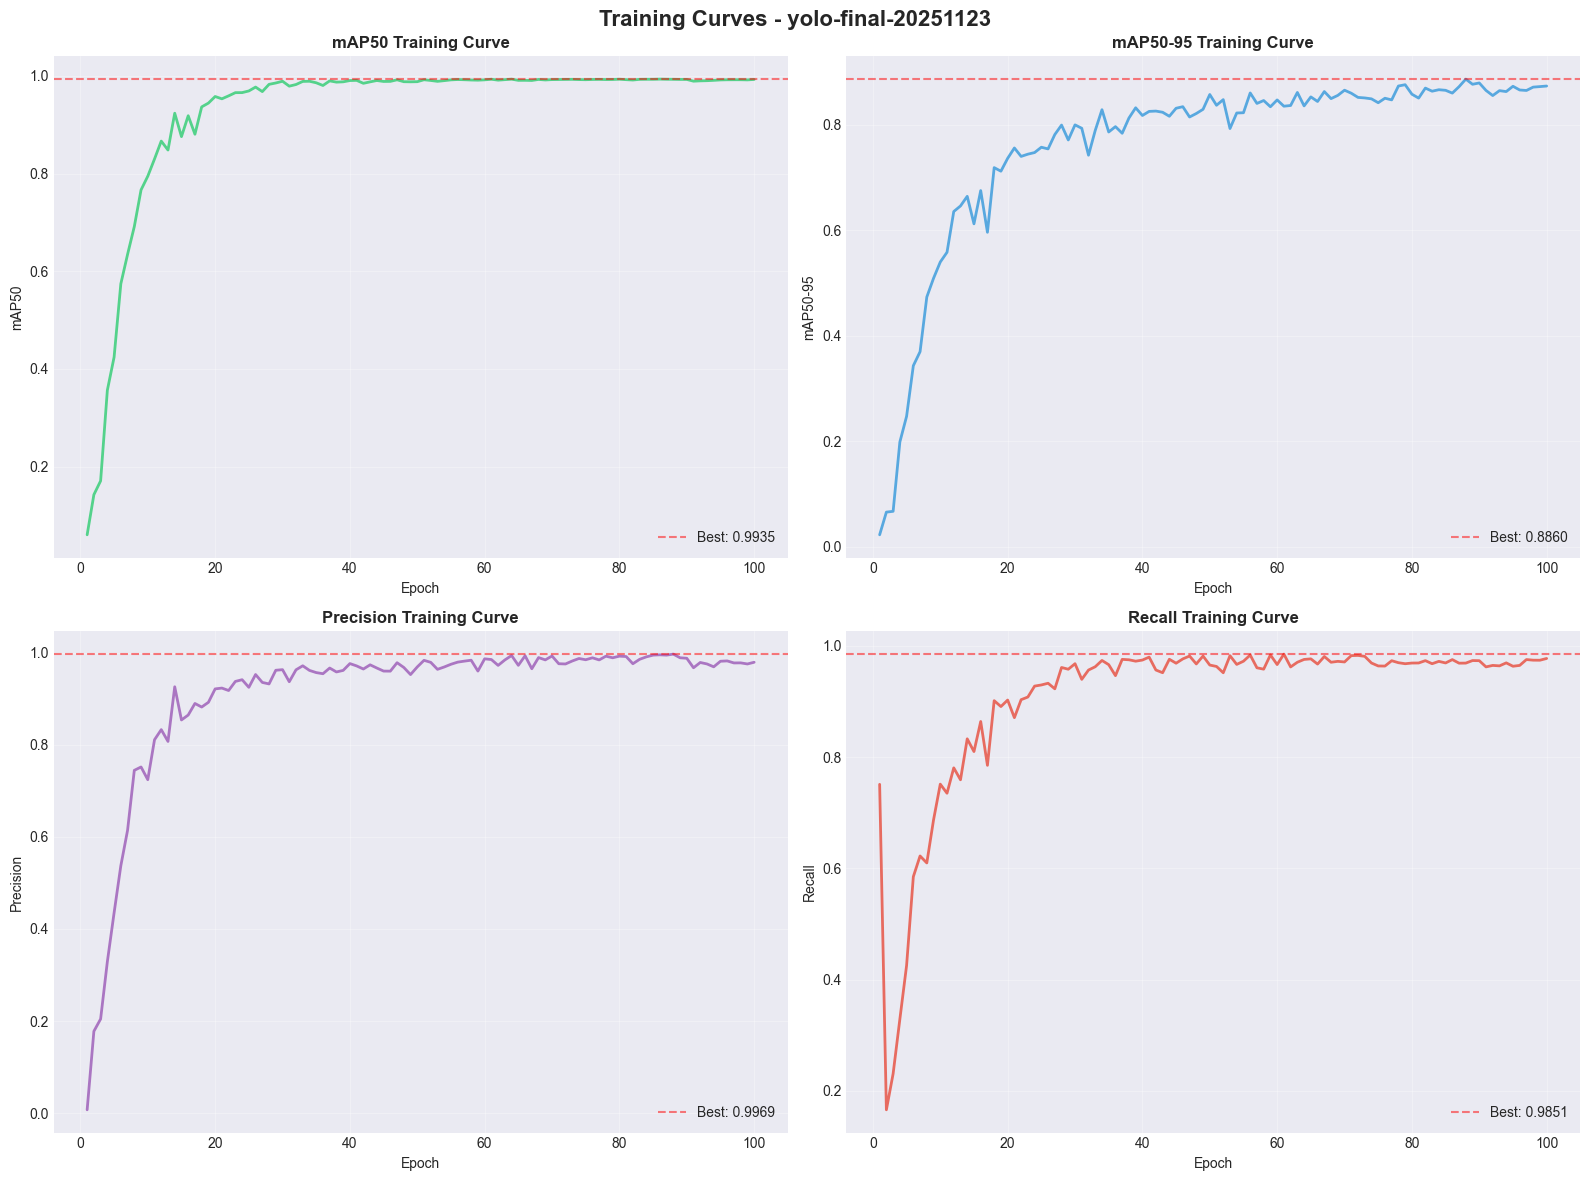

In [14]:
# Visualize training curves (only if model exists)
if best_model is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # mAP50
    axes[0, 0].plot(df['epoch'], df['metrics/mAP50(B)'], linewidth=2, color='#2ecc71', alpha=0.8)
    axes[0, 0].axhline(y=df['metrics/mAP50(B)'].max(), color='red', linestyle='--', alpha=0.5, 
                       label=f"Best: {df['metrics/mAP50(B)'].max():.4f}")
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('mAP50')
    axes[0, 0].set_title('mAP50 Training Curve', fontweight='bold')
    axes[0, 0].legend(loc='lower right')
    axes[0, 0].grid(True, alpha=0.3)
    
    # mAP50-95
    axes[0, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'], linewidth=2, color='#3498db', alpha=0.8)
    axes[0, 1].axhline(y=df['metrics/mAP50-95(B)'].max(), color='red', linestyle='--', alpha=0.5,
                       label=f"Best: {df['metrics/mAP50-95(B)'].max():.4f}")
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('mAP50-95')
    axes[0, 1].set_title('mAP50-95 Training Curve', fontweight='bold')
    axes[0, 1].legend(loc='lower right')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[1, 0].plot(df['epoch'], df['metrics/precision(B)'], linewidth=2, color='#9b59b6', alpha=0.8)
    axes[1, 0].axhline(y=df['metrics/precision(B)'].max(), color='red', linestyle='--', alpha=0.5,
                       label=f"Best: {df['metrics/precision(B)'].max():.4f}")
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].set_title('Precision Training Curve', fontweight='bold')
    axes[1, 0].legend(loc='lower right')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 1].plot(df['epoch'], df['metrics/recall(B)'], linewidth=2, color='#e74c3c', alpha=0.8)
    axes[1, 1].axhline(y=df['metrics/recall(B)'].max(), color='red', linestyle='--', alpha=0.5,
                       label=f"Best: {df['metrics/recall(B)'].max():.4f}")
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].set_title('Recall Training Curve', fontweight='bold')
    axes[1, 1].legend(loc='lower right')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Training Curves - {best_model["name"]}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping visualizations (no model data available)")

### 4c. Training Impact Analysis: Pre vs Post Fine-tuning

Comprehensive comparison of pretrained baseline with fine-tuned model to quantify the improvement and its effect on sample size requirements.

TRAINING IMPACT ANALYSIS: PRETRAINED vs FINE-TUNED

--------------------------------------------------------------------------------
PERFORMANCE COMPARISON
--------------------------------------------------------------------------------

Metric          Pretrained           Fine-tuned           Improvement         
--------------------------------------------------------------------------------
mAP50           0.0014 ( 0.14%)  0.9935 (99.35%)  +0.9921 (+70209.3%)
mAP50-95        0.0005 ( 0.05%)  0.8596 (85.96%)  +0.8591 (+184013.9%)
precision       0.0027 ( 0.27%)  0.9954 (99.54%)  +0.9927 (+36464.7%)
recall          0.0098 ( 0.98%)  0.9752 (97.52%)  +0.9654 (+9815.0%)

--------------------------------------------------------------------------------
SAMPLE SIZE REQUIREMENTS COMPARISON
--------------------------------------------------------------------------------

Target: 85% confidence interval with ±5% margin

Scenario                                 Accuracy     Base n     Ω-Adjust

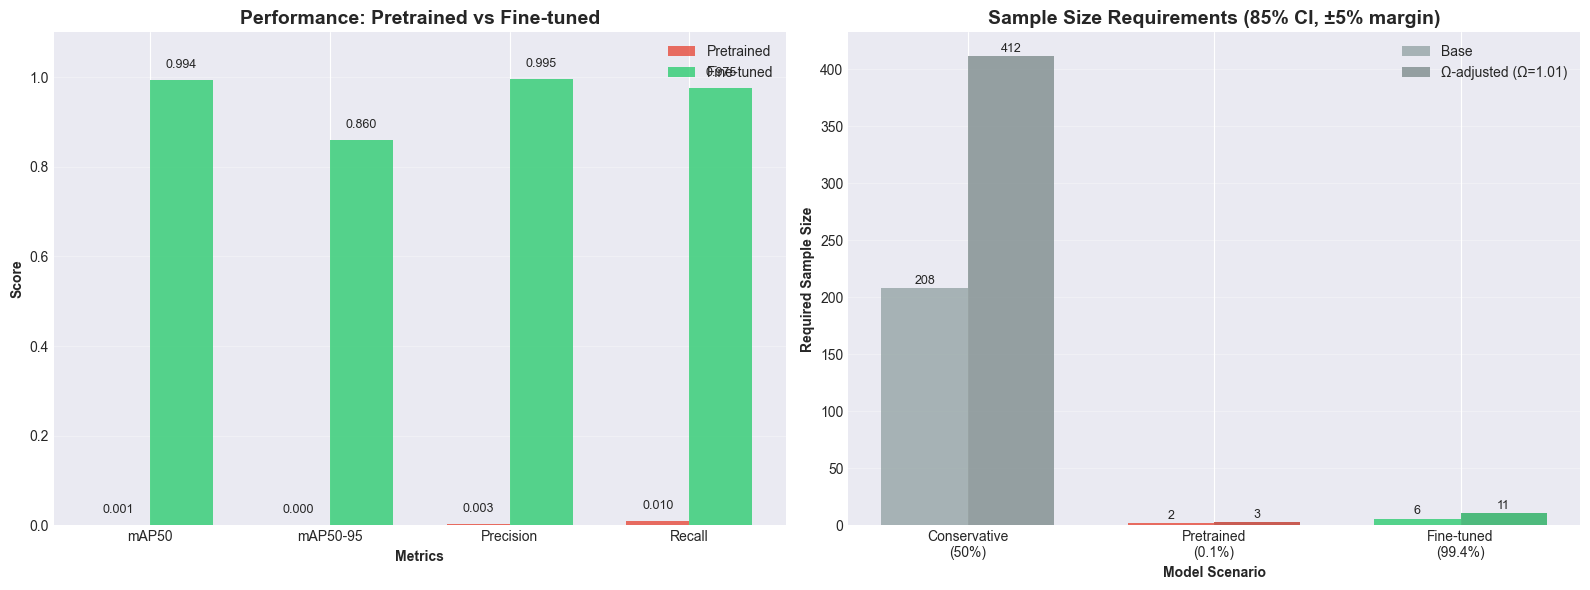


KEY INSIGHTS

✓ EXCELLENT TRAINING OUTCOME
  • Fine-tuned model achieved 99.35% accuracy
  • This is a 70209.3% improvement over pretrained
  • Sample size reduced by -4 samples (-200.0%)

📊 STATISTICAL VALIDITY:
  ✓ Test set (481 samples) exceeds requirements (6 needed)
  ✓ Results are statistically valid for 85% CI with ±5% margin

💡 VALUE OF TRAINING:
  • Training reduced sample requirements by 202 samples
  • This is a 97.1% reduction from conservative estimate
  • High accuracy = lower variance = fewer samples needed for same confidence



In [15]:
# Comprehensive comparison: Pretrained vs Fine-tuned
print("=" * 80)
print("TRAINING IMPACT ANALYSIS: PRETRAINED vs FINE-TUNED")
print("=" * 80)

if pretrained_metrics and best_model:
    print("\n" + "-" * 80)
    print("PERFORMANCE COMPARISON")
    print("-" * 80)
    print(f"\n{'Metric':<15} {'Pretrained':<20} {'Fine-tuned':<20} {'Improvement':<20}")
    print("-" * 80)
    
    metrics_to_compare = ['mAP50', 'mAP50-95', 'precision', 'recall']
    
    for metric in metrics_to_compare:
        pre_val = pretrained_metrics[metric]
        post_val = model_metrics[metric]
        improvement = post_val - pre_val
        improvement_pct = (improvement / pre_val * 100) if pre_val > 0 else 0
        
        print(f"{metric:<15} {pre_val:>6.4f} ({pre_val*100:>5.2f}%)  {post_val:>6.4f} ({post_val*100:>5.2f}%)  {improvement:>+6.4f} ({improvement_pct:>+6.1f}%)")
    
    # Sample size comparison
    print("\n" + "-" * 80)
    print("SAMPLE SIZE REQUIREMENTS COMPARISON")
    print("-" * 80)
    print(f"\nTarget: {desired_confidence*100:.0f}% confidence interval with ±{desired_margin*100:.0f}% margin\n")
    
    pretrained_accuracy = pretrained_metrics['mAP50']
    finetuned_accuracy = model_metrics['mAP50']
    
    required_n_pretrained = calculate_sample_size_with_actual_accuracy(
        actual_accuracy=pretrained_accuracy,
        confidence_level=desired_confidence,
        margin_of_error=desired_margin
    )
    
    required_n_pretrained_omega = calculate_sample_size_with_actual_accuracy(
        actual_accuracy=pretrained_accuracy,
        confidence_level=desired_confidence,
        margin_of_error=desired_margin,
        omega=omega_data['omega']
    )
    
    required_n_finetuned = calculate_sample_size_with_actual_accuracy(
        actual_accuracy=finetuned_accuracy,
        confidence_level=desired_confidence,
        margin_of_error=desired_margin
    )
    
    required_n_finetuned_omega = calculate_sample_size_with_actual_accuracy(
        actual_accuracy=finetuned_accuracy,
        confidence_level=desired_confidence,
        margin_of_error=desired_margin,
        omega=omega_data['omega']
    )
    
    print(f"{'Scenario':<40} {'Accuracy':<12} {'Base n':<10} {'Ω-Adjusted n':<15}")
    print("-" * 85)
    print(f"{'Conservative (no model)':<40} {'50.00%':<12} {required_n_conservative:<10d} {required_n_conservative_omega:<15d}")
    print(f"{'Pretrained model (baseline)':<40} {f'{pretrained_accuracy*100:.2f}%':<12} {required_n_pretrained:<10d} {required_n_pretrained_omega:<15d}")
    print(f"{'Fine-tuned model (trained)':<40} {f'{finetuned_accuracy*100:.2f}%':<12} {required_n_finetuned:<10d} {required_n_finetuned_omega:<15d}")
    
    # Calculate reductions
    reduction_pre_to_fine = required_n_pretrained - required_n_finetuned
    reduction_cons_to_fine = required_n_conservative - required_n_finetuned
    reduction_pre_to_fine_omega = required_n_pretrained_omega - required_n_finetuned_omega
    reduction_cons_to_fine_omega = required_n_conservative_omega - required_n_finetuned_omega
    
    print("\n" + "-" * 80)
    print("SAMPLE SIZE REDUCTIONS FROM TRAINING")
    print("-" * 80)
    print(f"\nBase calculations (no Omega):")
    print(f"  Pretrained → Fine-tuned: {reduction_pre_to_fine} samples ({(reduction_pre_to_fine/required_n_pretrained*100):.1f}% fewer)")
    print(f"  Conservative → Fine-tuned: {reduction_cons_to_fine} samples ({(reduction_cons_to_fine/required_n_conservative*100):.1f}% fewer)")
    
    print(f"\nOmega-adjusted (Ω={omega_data['omega']:.2f}):")
    print(f"  Pretrained → Fine-tuned: {reduction_pre_to_fine_omega} samples ({(reduction_pre_to_fine_omega/required_n_pretrained_omega*100):.1f}% fewer)")
    print(f"  Conservative → Fine-tuned: {reduction_cons_to_fine_omega} samples ({(reduction_cons_to_fine_omega/required_n_conservative_omega*100):.1f}% fewer)")
    # Visualize the comparison
    print("\n" + "-" * 80)
    print("VISUAL COMPARISON")
    print("-" * 80)
    
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Performance metrics comparison
    metrics_labels = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
    pre_values = [pretrained_metrics[m] for m in metrics_to_compare]
    post_values = [model_metrics[m] for m in metrics_to_compare]
    
    x = np.arange(len(metrics_labels))
    width = 0.35
    
    axes[0].bar(x - width/2, pre_values, width, label='Pretrained', alpha=0.8, color='#e74c3c')
    axes[0].bar(x + width/2, post_values, width, label='Fine-tuned', alpha=0.8, color='#2ecc71')
    axes[0].set_xlabel('Metrics', fontweight='bold')
    axes[0].set_ylabel('Score', fontweight='bold')
    axes[0].set_title('Performance: Pretrained vs Fine-tuned', fontweight='bold', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics_labels)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].set_ylim([0, 1.1])
    
    # Add value labels on bars
    for i, (pre, post) in enumerate(zip(pre_values, post_values)):
        axes[0].text(i - width/2, pre + 0.02, f'{pre:.3f}', ha='center', va='bottom', fontsize=9)
        axes[0].text(i + width/2, post + 0.02, f'{post:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Sample size requirements comparison (grouped bars for base vs Omega-adjusted)
    scenarios = ['Conservative\n(50%)', f'Pretrained\n({pretrained_accuracy*100:.1f}%)', f'Fine-tuned\n({finetuned_accuracy*100:.1f}%)']
    sample_sizes_base = [required_n_conservative, required_n_pretrained, required_n_finetuned]
    sample_sizes_omega = [required_n_conservative_omega, required_n_pretrained_omega, required_n_finetuned_omega]
    
    x = np.arange(len(scenarios))
    width = 0.35
    
    bars1 = axes[1].bar(x - width/2, sample_sizes_base, width, label='Base', alpha=0.8, color=['#95a5a6', '#e74c3c', '#2ecc71'])
    bars2 = axes[1].bar(x + width/2, sample_sizes_omega, width, label=f'Ω-adjusted (Ω={omega_data["omega"]:.2f})', alpha=0.8, color=['#7f8c8d', '#c0392b', '#27ae60'])
    
    axes[1].set_xlabel('Model Scenario', fontweight='bold')
    axes[1].set_ylabel('Required Sample Size', fontweight='bold')
    axes[1].set_title('Sample Size Requirements (85% CI, ±5% margin)', fontweight='bold', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(scenarios)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, size in zip(bars1, sample_sizes_base):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{int(size)}',
                    ha='center', va='bottom', fontsize=9)
    
    for bar, size in zip(bars2, sample_sizes_omega):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{int(size)}',
                    ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Key insights
    print("\n" + "=" * 80)
    print("KEY INSIGHTS")
    print("=" * 80)
    
    if finetuned_accuracy > 0.95:
        print(f"\n✓ EXCELLENT TRAINING OUTCOME")
        print(f"  • Fine-tuned model achieved {finetuned_accuracy*100:.2f}% accuracy")
        print(f"  • This is a {((finetuned_accuracy - pretrained_accuracy) / pretrained_accuracy * 100):.1f}% improvement over pretrained")
        print(f"  • Sample size reduced by {reduction_pre_to_fine} samples ({(reduction_pre_to_fine/required_n_pretrained*100):.1f}%)")
    elif finetuned_accuracy > 0.85:
        print(f"\n✓ STRONG TRAINING OUTCOME")
        print(f"  • Fine-tuned model achieved {finetuned_accuracy*100:.2f}% accuracy")
        print(f"  • This represents significant improvement over pretrained baseline")
        print(f"  • Sample size substantially reduced from pretrained requirements")
    else:
        print(f"\n⚠ MODERATE TRAINING OUTCOME")
        print(f"  • Fine-tuned model achieved {finetuned_accuracy*100:.2f}% accuracy")
        print(f"  • Consider additional training, augmentation, or hyperparameter tuning")
    
    print(f"\n📊 STATISTICAL VALIDITY:")
    test_samples = composition_stats.get('testing', {}).get('augmented', 0)
    if test_samples >= required_n_finetuned:
        print(f"  ✓ Test set ({test_samples} samples) exceeds requirements ({required_n_finetuned} needed)")
        print(f"  ✓ Results are statistically valid for {desired_confidence*100:.0f}% CI with ±{desired_margin*100:.0f}% margin")
    else:
        shortfall = required_n_finetuned - test_samples
        print(f"  ⚠ Test set ({test_samples} samples) below requirements ({required_n_finetuned} needed)")
        print(f"  ⚠ Need {shortfall} more samples for full statistical validity")
    
    print(f"\n💡 VALUE OF TRAINING:")
    print(f"  • Training reduced sample requirements by {reduction_cons_to_fine} samples")
    print(f"  • This is a {(reduction_cons_to_fine/required_n_conservative*100):.1f}% reduction from conservative estimate")
    print(f"  • High accuracy = lower variance = fewer samples needed for same confidence")
    
elif pretrained_metrics:
    print("\n⚠ Fine-tuned model not available for comparison")
    print(f"  Pretrained baseline: {pretrained_metrics['mAP50']*100:.2f}% mAP50")
else:
    print("\n⚠ Cannot perform comparison - models not evaluated")

print("\n" + "=" * 80)

## 5. Integrated Summary & Recommendations {#summary}

Combined analysis and actionable recommendations based on all three analyses.

In [16]:
# Generate integrated summary
print("=" * 80)
print("INTEGRATED ANALYSIS SUMMARY")
print("=" * 80)

print("\n1. DATASET VARIABILITY (OMEGA)")
print("-" * 80)
print(f"   Omega Value: {omega_data['omega']:.2f}")
print(f"   Variability: {omega_data['variability_level']}")
print(f"   Interpretation: ", end="")
if omega_data['omega'] > 10:
    print("Low inter-image variability - images are similar")
elif omega_data['omega'] > 5:
    print("Moderate inter-image variability - typical dataset")
else:
    print("High inter-image variability - diverse images")

print("\n2. DATASET COMPOSITION")
print("-" * 80)
print(f"   Total original images:  {total_original}")
print(f"   Total augmented samples: {total_augmented}")
print(f"   Augmentation ratio: {total_augmented/total_original:.1f}x" if total_original > 0 else "   Augmentation ratio: N/A")
print(f"   Training:   {composition_stats.get('training', {}).get('total', 0):4d} samples")
print(f"   Validation: {composition_stats.get('validation', {}).get('total', 0):4d} samples")
print(f"   Testing:    {composition_stats.get('testing', {}).get('total', 0):4d} samples")

print("\n3. STATISTICAL VALIDITY")
print("-" * 80)
print(f"   Required samples (85% CI, ±5%): {required_n_conservative}")
print(f"   Available samples: {total_augmented}")
if total_augmented >= required_n_conservative:
    print(f"   Status: ✓ SUFFICIENT")
else:
    print(f"   Status: ⚠ INSUFFICIENT (need {required_n_conservative - total_augmented} more)")

print("\n4. MODEL PERFORMANCE")
print("-" * 80)

# Pretrained baseline
if pretrained_metrics:
    print(f"\n   Pretrained Baseline:")
    print(f"   mAP50:     {pretrained_metrics['mAP50']:.4f} ({pretrained_metrics['mAP50']*100:.2f}%)")
    print(f"   Required samples: {calculate_sample_size_with_actual_accuracy(pretrained_metrics['mAP50'], desired_confidence, desired_margin)} images")

# Fine-tuned model
if best_model:
    print(f"\n   Fine-tuned Model: {model_metrics['name']}")
    print(f"   mAP50:     {model_metrics['mAP50']:.4f} ({model_metrics['mAP50']*100:.2f}%)")
    print(f"   mAP50-95:  {model_metrics['mAP50-95']:.4f} ({model_metrics['mAP50-95']*100:.2f}%)")
    print(f"   Precision: {model_metrics['precision']:.4f} ({model_metrics['precision']*100:.2f}%)")
    print(f"   Recall:    {model_metrics['recall']:.4f} ({model_metrics['recall']*100:.2f}%)")
    print(f"   Required samples: {calculate_sample_size_with_actual_accuracy(model_metrics['mAP50'], desired_confidence, desired_margin)} images")
    
    # Performance assessment
    if model_metrics['mAP50'] > 0.95:
        print(f"   Assessment: ⭐⭐⭐⭐⭐ EXCELLENT - Production ready")
    elif model_metrics['mAP50'] > 0.90:
        print(f"   Assessment: ⭐⭐⭐⭐ VERY GOOD - Strong performance")
    elif model_metrics['mAP50'] > 0.85:
        print(f"   Assessment: ⭐⭐⭐ GOOD - Reliable performance")
    elif model_metrics['mAP50'] > 0.75:
        print(f"   Assessment: ⭐⭐ ACCEPTABLE - Functional with room for improvement")
    else:
        print(f"   Assessment: ⭐ NEEDS IMPROVEMENT")
    
    # Training improvement
    if pretrained_metrics:
        improvement = model_metrics['mAP50'] - pretrained_metrics['mAP50']
        improvement_pct = (improvement / pretrained_metrics['mAP50'] * 100) if pretrained_metrics['mAP50'] > 0 else 0
        print(f"\n   Training Improvement: +{improvement:.4f} ({improvement_pct:+.1f}%)")
else:
    print("   No trained model available")

print("\n" + "=" * 80)
print("RECOMMENDATIONS")
print("=" * 80)

recommendations = []

# Dataset recommendations
if total_augmented < required_n_conservative:
    recommendations.append(
        f"1. DATASET: Increase augmented samples by {required_n_conservative - total_augmented} "
        f"to meet statistical validity requirements"
    )
else:
    recommendations.append(
        "1. DATASET: ✓ Sample size is sufficient for statistical validity"
    )

# Variability recommendations
if omega_data['omega'] < 5:
    recommendations.append(
        "2. VARIABILITY: High diversity detected - ensure augmentation strategies "
        "cover the full range of document variations"
    )
elif omega_data['omega'] > 10:
    recommendations.append(
        "2. VARIABILITY: Low diversity detected - consider adding more diverse "
        "document types to improve generalization"
    )
else:
    recommendations.append(
        "2. VARIABILITY: ✓ Moderate diversity - good balance achieved"
    )

# Model recommendations
if best_model:
    if model_metrics['mAP50'] < 0.90:
        recommendations.append(
            "3. MODEL: Performance can be improved - consider hyperparameter tuning, "
            "longer training, or better augmentation strategies"
        )
    else:
        recommendations.append(
            "3. MODEL: ✓ Strong performance achieved - ready for deployment"
        )
    
    # Precision-Recall balance
    if abs(model_metrics['precision'] - model_metrics['recall']) > 0.1:
        if model_metrics['precision'] > model_metrics['recall']:
            recommendations.append(
                "   → Precision higher than recall - model is missing some text regions. "
                "Consider adjusting confidence threshold or using more diverse training data"
            )
        else:
            recommendations.append(
                "   → Recall higher than precision - model has some false detections. "
                "Consider increasing confidence threshold or refining augmentation"
            )
else:
    recommendations.append(
        "3. MODEL: No trained model found - train a baseline model to evaluate performance"
    )

# Validation strategy
n_val = composition_stats.get('validation', {}).get('augmented', 0)
if n_val < 50:
    recommendations.append(
        f"4. VALIDATION: Validation set ({n_val} samples) is small - "
        "consider expanding for more reliable confidence intervals"
    )
else:
    recommendations.append(
        f"4. VALIDATION: ✓ Validation set size ({n_val} samples) is adequate"
    )

# Print recommendations
for rec in recommendations:
    print(f"\n{rec}")

print("\n" + "=" * 80)

INTEGRATED ANALYSIS SUMMARY

1. DATASET VARIABILITY (OMEGA)
--------------------------------------------------------------------------------
   Omega Value: 1.01
   Variability: High
   Interpretation: High inter-image variability - diverse images

2. DATASET COMPOSITION
--------------------------------------------------------------------------------
   Total original images:  0
   Total augmented samples: 3359
   Augmentation ratio: N/A
   Training:   2224 samples
   Validation:  654 samples
   Testing:     481 samples

3. STATISTICAL VALIDITY
--------------------------------------------------------------------------------
   Required samples (85% CI, ±5%): 208
   Available samples: 3359
   Status: ✓ SUFFICIENT

4. MODEL PERFORMANCE
--------------------------------------------------------------------------------

   Pretrained Baseline:
   mAP50:     0.0014 (0.14%)
   Required samples: 2 images

   Fine-tuned Model: yolo-final-20251123
   mAP50:     0.9935 (99.35%)
   mAP50-95:  0.859

In [17]:
# Export integrated report
report_path = OUTPUT_DIR / "integrated_analysis_report.md"

with open(report_path, 'w') as f:
    f.write("# Integrated Dataset & Model Analysis Report\n\n")
    f.write(f"**Analysis Date:** {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}\n\n")
    
    f.write("## 1. Dataset Variability (Omega)\n\n")
    f.write(f"- **Omega Value:** {omega_data['omega']:.2f}\n")
    f.write(f"- **Variability Level:** {omega_data['variability_level']}\n")
    f.write(f"- **Number of Images:** {omega_data.get('num_images', 'N/A')}\n\n")
    
    f.write("## 2. Dataset Composition\n\n")
    f.write(f"- **Total Original Images:** {total_original}\n")
    f.write(f"- **Total Augmented Samples:** {total_augmented}\n")
    f.write(f"- **Augmentation Ratio:** {total_augmented/total_original:.1f}x\n\n" if total_original > 0 else "- **Augmentation Ratio:** N/A\n\n")
    
    for split_name, stats in composition_stats.items():
        f.write(f"### {split_name.title()}\n")
        f.write(f"- Original: {stats['original']}\n")
        f.write(f"- Augmented: {stats['augmented']}\n")
        f.write(f"- Total: {stats['total']}\n\n")
    
    f.write("## 3. Statistical Validity\n\n")
    f.write(f"- **Target:** 85% confidence interval with ±5% margin\n")
    f.write(f"- **Required Samples:** {required_n_conservative}\n")
    f.write(f"- **Available Samples:** {total_augmented}\n")
    f.write(f"- **Status:** {'✓ SUFFICIENT' if total_augmented >= required_n_conservative else '⚠ INSUFFICIENT'}\n\n")
    
    f.write("## 4. Model Performance\n\n")
    
    # Pretrained baseline
    if pretrained_metrics:
        f.write("### Pretrained Baseline\n\n")
        f.write(f"- **Model:** {pretrained_metrics['model']}\n")
        f.write(f"- **mAP50:** {pretrained_metrics['mAP50']:.4f} ({pretrained_metrics['mAP50']*100:.2f}%)\n")
        f.write(f"- **mAP50-95:** {pretrained_metrics['mAP50-95']:.4f} ({pretrained_metrics['mAP50-95']*100:.2f}%)\n")
        f.write(f"- **Precision:** {pretrained_metrics['precision']:.4f} ({pretrained_metrics['precision']*100:.2f}%)\n")
        f.write(f"- **Recall:** {pretrained_metrics['recall']:.4f} ({pretrained_metrics['recall']*100:.2f}%)\n")
        f.write(f"- **Required Sample Size:** {calculate_sample_size_with_actual_accuracy(pretrained_metrics['mAP50'], desired_confidence, desired_margin)} images\n\n")
    
    # Fine-tuned model
    if best_model:
        f.write("### Fine-tuned Model\n\n")
        f.write(f"- **Model:** {model_metrics['name']}\n")
        f.write(f"- **mAP50:** {model_metrics['mAP50']:.4f} ({model_metrics['mAP50']*100:.2f}%)\n")
        f.write(f"- **mAP50-95:** {model_metrics['mAP50-95']:.4f} ({model_metrics['mAP50-95']*100:.2f}%)\n")
        f.write(f"- **Precision:** {model_metrics['precision']:.4f} ({model_metrics['precision']*100:.2f}%)\n")
        f.write(f"- **Recall:** {model_metrics['recall']:.4f} ({model_metrics['recall']*100:.2f}%)\n")
        f.write(f"- **Required Sample Size:** {calculate_sample_size_with_actual_accuracy(model_metrics['mAP50'], desired_confidence, desired_margin)} images\n\n")
        
        if pretrained_metrics:
            improvement = model_metrics['mAP50'] - pretrained_metrics['mAP50']
            improvement_pct = (improvement / pretrained_metrics['mAP50'] * 100) if pretrained_metrics['mAP50'] > 0 else 0
            f.write(f"**Training Improvement:** +{improvement:.4f} ({improvement_pct:+.1f}%)\n\n")
    
    f.write("## 5. Recommendations\n\n")
    for i, rec in enumerate(recommendations, 1):
        f.write(f"{rec}\n\n")

print(f"\n✓ Integrated analysis report exported to: {report_path}")


✓ Integrated analysis report exported to: d:\docs\MADS\699\data\output\integrated_analysis_report.md


## Conclusion

This integrated notebook combines dataset variability analysis, statistical validation, and YOLO model performance evaluation into a single comprehensive analysis tool. Run all cells sequentially to generate a complete assessment of your financial document text detection project.

**Key Outputs:**
- Omega value calculation for inter-image variability
- Dataset composition and statistical validity assessment
- Model performance metrics with confidence intervals
- Integrated recommendations for improvement
- Exported analysis report